# Adaptive DenseNet Layer - Paddy Disease Classification

This notebook trains the layer-gated Adaptive Sparse DenseNet121 model on Kaggle GPU.

In [1]:
import csv
import time
import random
from pathlib import Path
from collections import defaultdict, OrderedDict

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models.densenet import _DenseLayer
from PIL import Image

print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('gpu:', torch.cuda.get_device_name(0))

torch: 2.10.0+cu128
cuda available: True
gpu: Tesla T4


In [2]:
SEED = 42
DATA_DIR = Path('/kaggle/input/competitions/paddy-disease-classification')
OUTPUT_DIR = Path('/kaggle/working/adaptive_densenet_layer')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NUM_CLASSES = 10
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 30
LR = 1e-4
WEIGHT_DECAY = 1e-4
SPARSITY_LAMBDA = 5e-4
GATE_INIT = 2.0
VAL_RATIO = 0.2
PATIENCE = 6
NUM_WORKERS = 3

random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [3]:
class ScalarGate(nn.Module):
    def __init__(self, init_value=2.0):
        super().__init__()
        self.logit = nn.Parameter(torch.tensor(float(init_value)))

    def forward(self, x):
        return torch.sigmoid(self.logit) * x

    @property
    def value(self):
        return torch.sigmoid(self.logit)


class GatedDenseLayer(nn.Module):
    def __init__(self, dense_layer, init_value=2.0):
        super().__init__()
        self.dense_layer = dense_layer
        self.gate = ScalarGate(init_value)

    def forward(self, features):
        return self.gate(self.dense_layer(features))


class GatedDenseBlock(nn.ModuleDict):
    def __init__(self, denseblock, init_value=2.0):
        super().__init__()
        for name, layer in denseblock.named_children():
            if not isinstance(layer, _DenseLayer):
                raise TypeError(f'Expected _DenseLayer, got {type(layer)}')
            self.add_module(name, GatedDenseLayer(layer, init_value))

    def forward(self, init_features):
        features = [init_features]
        for _, layer in self.items():
            new_features = layer(features)
            features.append(new_features)
        return torch.cat(features, 1)


class ZeroDenseLayer(nn.Module):
    def __init__(self, growth_rate):
        super().__init__()
        self.growth_rate = int(growth_rate)

    def forward(self, features):
        x = features[0]
        return x.new_zeros(x.shape[0], self.growth_rate, x.shape[2], x.shape[3])


class AdaptiveDenseNet121(nn.Module):
    def __init__(self, num_classes, pretrained=True, gate_init=2.0):
        super().__init__()
        weights = models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.densenet121(weights=weights)
        in_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Linear(in_features, num_classes)
        for name, module in list(self.backbone.features.named_children()):
            if name.startswith('denseblock'):
                setattr(self.backbone.features, name, GatedDenseBlock(module, gate_init))

    def forward(self, x):
        features = self.backbone.features(x)
        out = F.relu(features, inplace=True)
        out = F.adaptive_avg_pool2d(out, (1, 1))
        out = torch.flatten(out, 1)
        return self.backbone.classifier(out)

    def sparsity_loss(self):
        values = [m.value.abs() for m in self.modules() if isinstance(m, ScalarGate)]
        return torch.stack(values).sum() if values else torch.zeros((), device=next(self.parameters()).device)

    def gate_values(self):
        return {name: float(m.value.detach().cpu()) for name, m in self.named_modules() if isinstance(m, ScalarGate)}


def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


def model_size_mb(model):
    total = sum(t.numel() * t.element_size() for t in list(model.parameters()) + list(model.buffers()))
    return total / (1024 * 1024)


def prune_model(model, threshold=0.8):
    for block in model.backbone.features.modules():
        if isinstance(block, GatedDenseBlock):
            for name, layer in list(block.items()):
                if isinstance(layer, GatedDenseLayer) and float(layer.gate.value.detach().cpu()) < threshold:
                    growth_rate = layer.dense_layer.conv2.out_channels
                    setattr(block, name, ZeroDenseLayer(growth_rate))
    return model

In [4]:
def read_train_csv(csv_path):
    rows = []
    with open(csv_path, newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            rows.append((row['image_id'], row['label']))
    return rows


def stratified_split(rows, val_ratio=0.2, seed=42):
    rng = random.Random(seed)
    by_class = defaultdict(list)
    for image_id, label in rows:
        by_class[label].append((image_id, label))
    train_rows, val_rows = [], []
    for label, items in sorted(by_class.items()):
        rng.shuffle(items)
        val_count = max(1, round(len(items) * val_ratio))
        val_rows.extend(items[:val_count])
        train_rows.extend(items[val_count:])
    rng.shuffle(train_rows)
    rng.shuffle(val_rows)
    return train_rows, val_rows


class PaddyDataset(Dataset):
    def __init__(self, rows, image_root, class_to_idx, transform=None):
        self.rows = rows
        self.image_root = Path(image_root)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.rows)

    def _image_path(self, image_id, label):
        nested = self.image_root / label / image_id
        if nested.exists():
            return nested
        flat = self.image_root / image_id
        if flat.exists():
            return flat
        raise FileNotFoundError(f'Missing image: {nested} or {flat}')

    def __getitem__(self, idx):
        image_id, label = self.rows[idx]
        image = Image.open(self._image_path(image_id, label)).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)
        return image, self.class_to_idx[label]


rows = read_train_csv(DATA_DIR / 'train.csv')
class_names = sorted({label for _, label in rows})
class_to_idx = {name: i for i, name in enumerate(class_names)}
train_rows, val_rows = stratified_split(rows, VAL_RATIO, SEED)

imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std = (0.229, 0.224, 0.225)
train_tfms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])
val_tfms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

train_ds = PaddyDataset(train_rows, DATA_DIR / 'train_images', class_to_idx, train_tfms)
val_ds = PaddyDataset(val_rows, DATA_DIR / 'train_images', class_to_idx, val_tfms)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(), persistent_workers=NUM_WORKERS > 0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(), persistent_workers=NUM_WORKERS > 0)

print('classes:', class_names)
print('train:', len(train_ds))
print('val:', len(val_ds))

classes: ['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']
train: 8325
val: 2082


In [5]:
def classification_metrics(y_true, y_pred, num_classes):
    cm = [[0 for _ in range(num_classes)] for _ in range(num_classes)]
    for t, p in zip(y_true, y_pred):
        cm[t][p] += 1
    precisions, recalls, f1s = [], [], []
    for c in range(num_classes):
        tp = cm[c][c]
        fp = sum(cm[r][c] for r in range(num_classes) if r != c)
        fn = sum(cm[c][r] for r in range(num_classes) if r != c)
        precision = tp / (tp + fp) if tp + fp > 0 else 0.0
        recall = tp / (tp + fn) if tp + fn > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0.0
        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
    correct = sum(cm[c][c] for c in range(num_classes))
    return {
        'accuracy': correct / len(y_true),
        'precision': sum(precisions) / num_classes,
        'recall': sum(recalls) / num_classes,
        'f1': sum(f1s) / num_classes,
        'confusion_matrix': cm,
    }


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0
    y_true, y_pred = [], []
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with torch.amp.autocast(device_type=device.type, enabled=device.type == 'cuda'):
            logits = model(images)
            loss = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(1)
        y_true.extend(labels.cpu().tolist())
        y_pred.extend(preds.cpu().tolist())
    metrics = classification_metrics(y_true, y_pred, NUM_CLASSES)
    metrics['loss'] = total_loss / len(loader.dataset)
    return metrics

In [6]:
model = AdaptiveDenseNet121(NUM_CLASSES, pretrained=True, gate_init=GATE_INIT).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler('cuda', enabled=device.type == 'cuda')

print('parameters:', count_parameters(model))
print('size_mb:', round(model_size_mb(model), 2))
print('gate_count:', len(model.gate_values()))

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 193MB/s]


parameters: 6964164
size_mb: 26.89
gate_count: 58


In [7]:
best_f1 = -1.0
bad_epochs = 0
best_path = OUTPUT_DIR / 'best_model.pt'
metrics_path = OUTPUT_DIR / 'metrics.csv'
gates_path = OUTPUT_DIR / 'gate_values.csv'

with open(metrics_path, 'w', newline='', encoding='utf-8') as f:
    csv.writer(f).writerow(['epoch', 'train_loss', 'train_ce_loss', 'train_acc', 'val_loss', 'val_acc', 'val_precision', 'val_recall', 'val_f1'])
with open(gates_path, 'w', newline='', encoding='utf-8') as f:
    csv.writer(f).writerow(['epoch', 'gate', 'value'])

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    model.train()
    total_loss = 0.0
    total_ce = 0.0
    correct = 0
    seen = 0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=device.type == 'cuda'):
            logits = model(images)
            ce_loss = criterion(logits, labels)
            loss = ce_loss + SPARSITY_LAMBDA * model.sparsity_loss()

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch = labels.size(0)
        total_loss += loss.item() * batch
        total_ce += ce_loss.item() * batch
        correct += (logits.argmax(1) == labels).sum().item()
        seen += batch

    train_loss = total_loss / seen
    train_ce = total_ce / seen
    train_acc = correct / seen
    val = evaluate(model, val_loader)
    gates = model.gate_values()

    with open(metrics_path, 'a', newline='', encoding='utf-8') as f:
        csv.writer(f).writerow([epoch, train_loss, train_ce, train_acc, val['loss'], val['accuracy'], val['precision'], val['recall'], val['f1']])
    with open(gates_path, 'a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        for name, value in gates.items():
            writer.writerow([epoch, name, value])

    if val['f1'] > best_f1:
        best_f1 = val['f1']
        bad_epochs = 0
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'metrics': val,
            'class_names': class_names,
            'parameters': count_parameters(model),
            'size_mb': model_size_mb(model),
            'gate_values': gates,
        }, best_path)
    else:
        bad_epochs += 1

    values = list(gates.values())
    elapsed = time.time() - start
    print(
        f"epoch={epoch:03d} train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
        f"val_loss={val['loss']:.4f} val_acc={val['accuracy']:.4f} val_f1={val['f1']:.4f} "
        f"gate_min={min(values):.4f} gate_mean={sum(values)/len(values):.4f} gate_max={max(values):.4f} "
        f"time={elapsed:.1f}s"
    )

    if bad_epochs >= PATIENCE:
        print(f'Early stopping at epoch {epoch}')
        break

print('best_f1:', best_f1)
print('best checkpoint:', best_path)

epoch=001 train_loss=1.0851 train_acc=0.6625 val_loss=0.5592 val_acc=0.8314 val_f1=0.7911 gate_min=0.8780 gate_mean=0.8784 gate_max=0.8806 time=95.5s
epoch=002 train_loss=0.4125 train_acc=0.8864 val_loss=0.3115 val_acc=0.9111 val_f1=0.8924 gate_min=0.8750 gate_mean=0.8756 gate_max=0.8785 time=52.6s
epoch=003 train_loss=0.2369 train_acc=0.9393 val_loss=0.2274 val_acc=0.9356 val_f1=0.9289 gate_min=0.8718 gate_mean=0.8726 gate_max=0.8758 time=52.5s
epoch=004 train_loss=0.1722 train_acc=0.9608 val_loss=0.1875 val_acc=0.9472 val_f1=0.9369 gate_min=0.8685 gate_mean=0.8696 gate_max=0.8728 time=52.2s
epoch=005 train_loss=0.1373 train_acc=0.9679 val_loss=0.1670 val_acc=0.9563 val_f1=0.9478 gate_min=0.8652 gate_mean=0.8665 gate_max=0.8698 time=52.5s
epoch=006 train_loss=0.1143 train_acc=0.9739 val_loss=0.1561 val_acc=0.9577 val_f1=0.9519 gate_min=0.8618 gate_mean=0.8632 gate_max=0.8666 time=52.6s
epoch=007 train_loss=0.1078 train_acc=0.9762 val_loss=0.1614 val_acc=0.9563 val_f1=0.9500 gate_min=0

In [8]:
checkpoint = torch.load(best_path, map_location=device)
model.load_state_dict(checkpoint['model_state'])
base_metrics = evaluate(model, val_loader)
base_params = count_parameters(model)
base_size = model_size_mb(model)
print('best_epoch:', checkpoint['epoch'])
print('unpruned_params:', base_params)
print('unpruned_size_mb:', round(base_size, 2))
base_metrics

best_epoch: 16
unpruned_params: 6964164
unpruned_size_mb: 26.89


{'accuracy': 0.9721421709894332,
 'precision': 0.9716443293374214,
 'recall': 0.966538156048764,
 'f1': 0.968918138886151,
 'confusion_matrix': [[91, 0, 0, 0, 1, 0, 0, 1, 0, 3],
  [0, 74, 0, 0, 0, 0, 2, 0, 0, 0],
  [0, 0, 66, 1, 0, 0, 0, 0, 0, 0],
  [1, 0, 0, 346, 0, 0, 0, 0, 0, 1],
  [1, 1, 0, 0, 183, 1, 1, 0, 0, 6],
  [0, 0, 1, 0, 0, 287, 0, 0, 0, 0],
  [0, 0, 0, 5, 5, 0, 111, 0, 1, 2],
  [1, 0, 0, 2, 0, 0, 1, 306, 8, 1],
  [0, 0, 0, 0, 0, 1, 2, 6, 344, 0],
  [0, 0, 0, 0, 0, 0, 0, 2, 0, 216]],
 'loss': 0.14410055170370684}

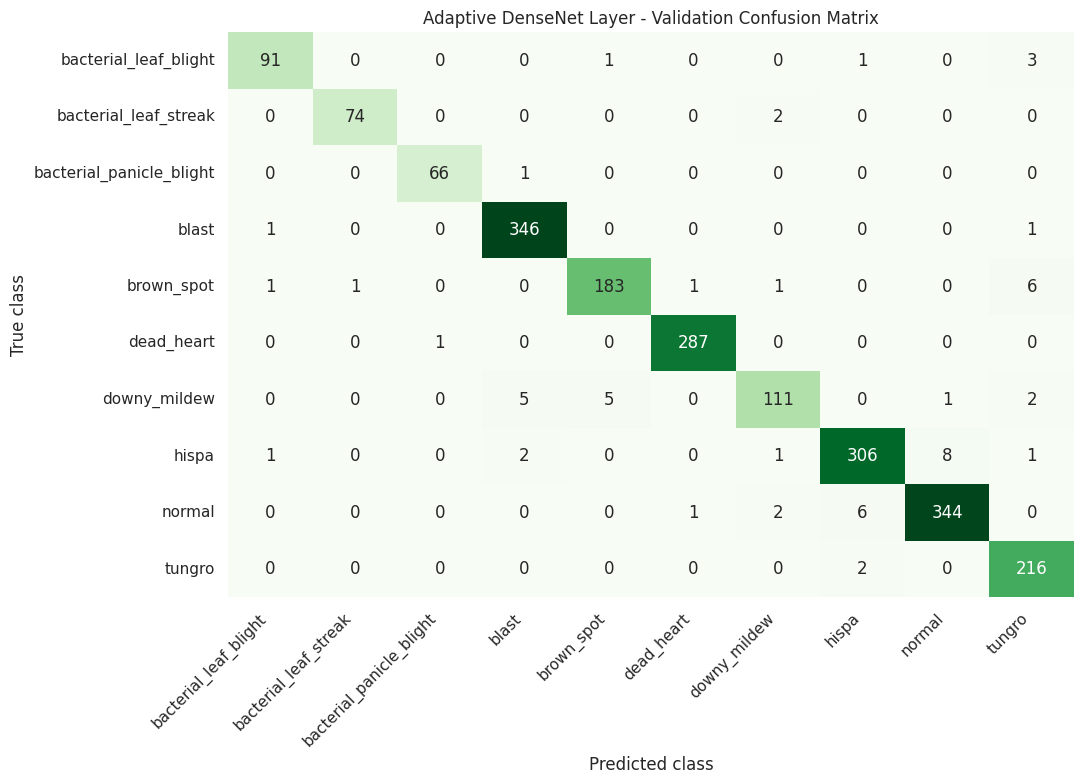

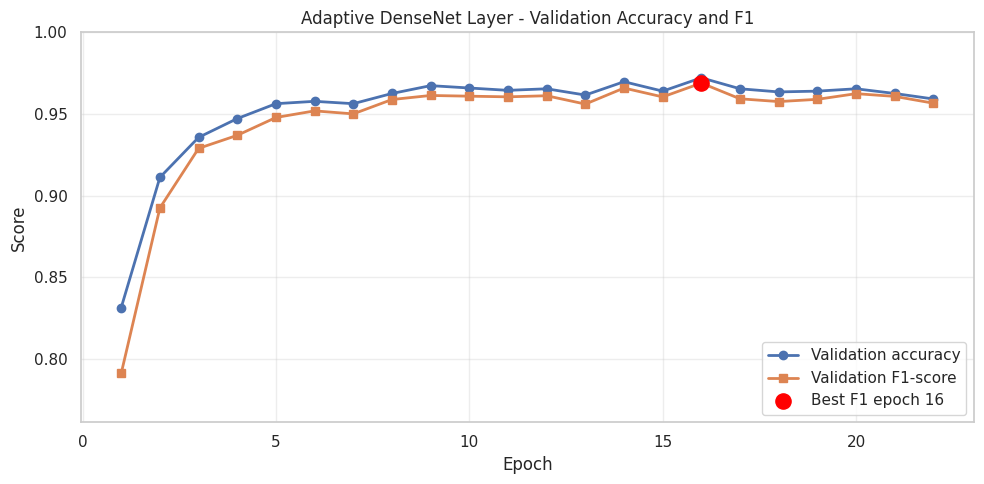

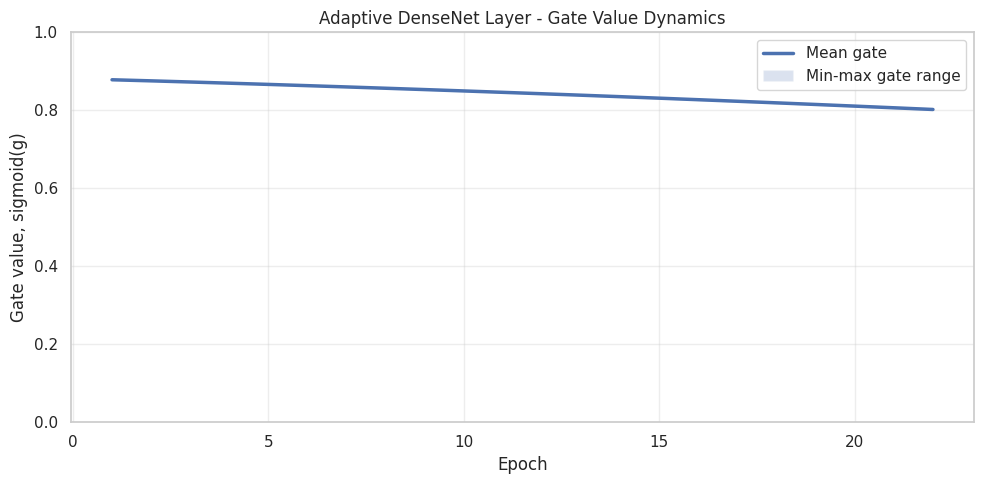

Saved figures:
/kaggle/working/adaptive_densenet_layer/confusion_matrix.png
/kaggle/working/adaptive_densenet_layer/validation_metrics.png
/kaggle/working/adaptive_densenet_layer/gate_dynamics.png


In [9]:
sns.set_theme(style='whitegrid', font_scale=1.0)

# Confusion matrix heatmap
cm = base_metrics['confusion_matrix']
plt.figure(figsize=(11, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=False,
)
plt.title('Adaptive DenseNet Layer - Validation Confusion Matrix')
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

# Validation accuracy and F1 curves
history = pd.read_csv(metrics_path)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history['epoch'], history['val_acc'], marker='o', linewidth=2, label='Validation accuracy')
ax.plot(history['epoch'], history['val_f1'], marker='s', linewidth=2, label='Validation F1-score')
best_idx = history['val_f1'].idxmax()
best_epoch = int(history.loc[best_idx, 'epoch'])
best_f1_value = history.loc[best_idx, 'val_f1']
ax.scatter([best_epoch], [best_f1_value], s=120, color='red', zorder=5, label=f'Best F1 epoch {best_epoch}')
ax.set_title('Adaptive DenseNet Layer - Validation Accuracy and F1')
ax.set_xlabel('Epoch')
ax.set_ylabel('Score')
ax.set_ylim(max(0.0, history[['val_acc', 'val_f1']].min().min() - 0.03), 1.0)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'validation_metrics.png', dpi=200, bbox_inches='tight')
plt.show()

# Gate dynamics summary
gate_history = pd.read_csv(gates_path)
gate_summary = gate_history.groupby('epoch')['value'].agg(['min', 'mean', 'max']).reset_index()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(gate_summary['epoch'], gate_summary['mean'], linewidth=2.5, label='Mean gate')
ax.fill_between(gate_summary['epoch'], gate_summary['min'], gate_summary['max'], alpha=0.2, label='Min-max gate range')
ax.set_title('Adaptive DenseNet Layer - Gate Value Dynamics')
ax.set_xlabel('Epoch')
ax.set_ylabel('Gate value, sigmoid(g)')
ax.set_ylim(0.0, 1.0)
ax.legend(loc='best')
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gate_dynamics.png', dpi=200, bbox_inches='tight')
plt.show()

print('Saved figures:')
print(OUTPUT_DIR / 'confusion_matrix.png')
print(OUTPUT_DIR / 'validation_metrics.png')
print(OUTPUT_DIR / 'gate_dynamics.png')

In [10]:
for threshold in [0.823, 0.825, 0.827, 0.829, 0.831, 0.833]:
    pruned = AdaptiveDenseNet121(NUM_CLASSES, pretrained=False, gate_init=GATE_INIT).to(device)
    pruned.load_state_dict(checkpoint['model_state'], strict=False)

    before_params = count_parameters(pruned)
    prune_model(pruned, threshold)
    after_params = count_parameters(pruned)

    metrics = evaluate(pruned, val_loader)
    print(
        f"threshold={threshold:.3f} params={before_params}->{after_params} "
        f"size_mb={model_size_mb(pruned):.2f} "
        f"acc={metrics['accuracy']:.4f} f1={metrics['f1']:.4f}"
    )


threshold=0.823 params=6964164->6964164 size_mb=26.89 acc=0.9721 f1=0.9689
threshold=0.825 params=6964164->6839683 size_mb=26.41 acc=0.9688 f1=0.9639
threshold=0.827 params=6964164->5111024 size_mb=19.73 acc=0.1720 f1=0.0505
threshold=0.829 params=6964164->1149389 size_mb=4.43 acc=0.1695 f1=0.0290
threshold=0.831 params=6964164->858827 size_mb=3.31 acc=0.1695 f1=0.0290
threshold=0.833 params=6964164->713546 size_mb=2.74 acc=0.1695 f1=0.0290


In [11]:
script_path = OUTPUT_DIR / 'adaptive_densenet_layer_torchscript.pt'
model.eval()
example = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)
traced = torch.jit.trace(model, example)
traced.save(str(script_path))
print('saved:', script_path)
print('metrics:', metrics_path)
print('gates:', gates_path)

saved: /kaggle/working/adaptive_densenet_layer/adaptive_densenet_layer_torchscript.pt
metrics: /kaggle/working/adaptive_densenet_layer/metrics.csv
gates: /kaggle/working/adaptive_densenet_layer/gate_values.csv
